In [2]:
import pandas as pd
import duckdb
import os
import os, json
from uuid import uuid4
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#pd.set_option("display.width", 500)  # adjusts total line width before wrapping
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
import faiss
from sklearn.preprocessing import normalize
import gspread
from gspread_dataframe import get_as_dataframe, set_with_dataframe
from google.oauth2 import service_account # based on google-auth library
import matplotlib.pyplot as plt
import re
import unicodedata
from sklearn.preprocessing import normalize
import numpy as np
import json
from sklearn.preprocessing import normalize
import numpy as np
import json
import math
from collections import defaultdict
from sklearn.preprocessing import normalize
import Levenshtein


In [3]:
try:
    file_data = json.load(open(os.path.expanduser("~/ServiceAccountsKey.json")))
    # (2) transform the content into crendentials object
    credentials = service_account.Credentials.from_service_account_info(file_data)
# (3) specify your usage of the credentials
    scoped_credentials = credentials.with_scopes(['https://spreadsheets.google.com/feeds', 'https://www.googleapis.com/auth/drive'])
# (4) use the constrained credentials for authentication of gspread package
    gc = gspread.Client(auth=scoped_credentials)
    grela_gs = gc.open_by_url("https://docs.google.com/spreadsheets/d/1QroTEQ9gQf9cLO9mvolp7fELNbYYjgvGd48yAiTj03w/edit?usp=sharing")
except:
    pass

In [5]:
vulgate_df = pd.read_parquet("../data/large_files/vulgate_df.parquet")

In [6]:
matches_long_df = pd.read_parquet("../data/register_ngram_matches_v4.parquet")

In [7]:
matches_long_df.sort_values("combined_score", ascending=False)

,source_sentence_id,register_ref,source_sentence,best_ngram,vulgate_text_clean,author,title,chapter,verse,best_raw_score,jaccard_sim,levenshtein_distance,levenshtein_sim,combined_score
1189,cc_10265_366,23;4,quare faciem tuam auertis obliuisceris inopiae nostrae et tribulationis nostrae,quare faciem tuam auertis obliuisceris inopiae nostrae et tribulationis nostrae,quare faciem tuam auertis obliuisceris inopiae nostrae et tribulationis nostrae,NaN,Psalmi,43,24,1.000000,1.0,0.000000,1.000000,1.000000
4355,cc_10265_1382,97;4,de quibus recte per prophetam dicitur obscurentur oculi eorum ne uideant et dorsum eorum semper incurua psal lxuiii quapropter quidquid illi contra uos imo contra iustitiam garriant et pro defende...,obscurentur oculi eorum ne uideant et dorsum eorum semper incurua,obscurentur oculi eorum ne uideant et dorsum eorum semper incurua,NaN,Psalmi,68,24,1.000000,1.0,0.000000,1.000000,1.000000
11391,cc_10265_3520,249;4,sitque semper in ore sit semper in corde uestro quod hunc uersiculum paucis interpositis sequitur et anima mea illi uiuet et semen meum seruiet ipsi,et anima mea illi uiuet et semen meum seruiet ipsi,et anima mea illi uiuet et semen meum seruiet ipsi,NaN,Psalmi,21,31,1.000000,1.0,0.000000,1.000000,1.000000
4356,cc_10265_1382,97;4,de quibus recte per prophetam dicitur obscurentur oculi eorum ne uideant et dorsum eorum semper incurua psal lxuiii quapropter quidquid illi contra uos imo contra iustitiam garriant et pro defende...,obscurentur oculi eorum ne uideant et dorsum eorum semper incurua,obscurentur oculi eorum ne uideant et dorsum illorum semper incurua,Paul of Tarsus,Romans,11,10,0.999012,0.9,0.030303,0.969697,0.956236
11064,cc_10265_3420,241;4,unde quia tu in eadem dioecesi positus es monemus et exhortamur tuam mihi dulcissimam charitatem et apostolica tibi auctoritate praecipimus ut si praefatum tullensem episcopum culpabilem indubitan...,enim alter alterius onera portate et sic adimplebitis legem christi,alter alterius onera portate et sic adimplebitis legem christi,Paul of Tarsus,Galatians,6,2,0.989442,0.9,0.038760,0.961240,0.950228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,cc_10265_4022,285;5,iii,iii,uicesima tertia dalaiau uicesima quarta mazziau,NaN,Paralipomenon I sive Chronicon I,24,18,0.760856,0.0,0.880000,0.120000,0.293619
6415,cc_10265_2042,150;5,xiii,xiii,uicesima tertia dalaiau uicesima quarta mazziau,NaN,Paralipomenon I sive Chronicon I,24,18,0.757764,0.0,0.882353,0.117647,0.291804
5642,cc_10265_1793,133;5,xiii,xiii,uicesima tertia dalaiau uicesima quarta mazziau,NaN,Paralipomenon I sive Chronicon I,24,18,0.757764,0.0,0.882353,0.117647,0.291804
6656,cc_10265_2117,155;5,xiii,xiii,uicesima tertia dalaiau uicesima quarta mazziau,NaN,Paralipomenon I sive Chronicon I,24,18,0.757764,0.0,0.882353,0.117647,0.291804


In [22]:
vulgate_df.head(10)

,sentence_id,grela_id,sentence_position,sent_text,author,title,tokens,chapter,verse,sent_text_clean
0,vulgate_tlg0031.tlg001.obi-lat_0,vulgate_tlg0031.tlg001.obi-lat,0,liber generationis Iesu Christi filii David filii Abraham,Novum Testamentum,Matthew,"[{'chapter': '1', 'char_end': 5, 'char_start': 0, 'lemma': 'liber', 'pos': 'ADJ', 'token_id': 255096949, 'token_text': 'liber', 'verse': '1'}, {'chapter': '1', 'char_end': 18, 'char_start': 6, 'le...",1,1,liber generationis iesu christi filii dauid filii abraham
1,vulgate_tlg0031.tlg001.obi-lat_1,vulgate_tlg0031.tlg001.obi-lat,1,Abraham genuit Isaac Isaac autem genuit Iacob Iacob autem genuit Iudam et fratres eius,Novum Testamentum,Matthew,"[{'chapter': '1', 'char_end': 7, 'char_start': 0, 'lemma': 'Abraham', 'pos': 'PROPN', 'token_id': 255096957, 'token_text': 'Abraham', 'verse': '2'}, {'chapter': '1', 'char_end': 14, 'char_start': ...",1,2,abraham genuit isaac isaac autem genuit iacob iacob autem genuit iudam et fratres eius
2,vulgate_tlg0031.tlg001.obi-lat_10,vulgate_tlg0031.tlg001.obi-lat,10,Iosias autem genuit Iechoniam et fratres eius in transmigratione Babylonis,Novum Testamentum,Matthew,"[{'chapter': '1', 'char_end': 6, 'char_start': 0, 'lemma': 'Iosias', 'pos': 'PROPN', 'token_id': 255097078, 'token_text': 'Iosias', 'verse': '11'}, {'chapter': '1', 'char_end': 12, 'char_start': 7...",1,11,iosias autem genuit iechoniam et fratres eius in transmigratione babylonis
3,vulgate_tlg0031.tlg001.obi-lat_100,vulgate_tlg0031.tlg001.obi-lat,100,beati estis cum maledixerint vobis et persecuti vos fuerint et dixerint omne malum adversum vos mentientes propter me,Novum Testamentum,Matthew,"[{'chapter': '5', 'char_end': 5, 'char_start': 0, 'lemma': 'beatus', 'pos': 'ADJ', 'token_id': 255098504, 'token_text': 'beati', 'verse': '11'}, {'chapter': '5', 'char_end': 11, 'char_start': 6, '...",5,11,beati estis cum maledixerint uobis et persecuti uos fuerint et dixerint omne malum aduersum uos mentientes propter me
4,vulgate_tlg0031.tlg001.obi-lat_1000,vulgate_tlg0031.tlg001.obi-lat,1000,congregatis ergo illis dixit Pilatus quem vultis dimittam vobis Barabban an Iesum qui dicitur Christus,Novum Testamentum,Matthew,"[{'chapter': '27', 'char_end': 11, 'char_start': 0, 'lemma': 'congrego', 'pos': 'VERB', 'token_id': 255112403, 'token_text': 'congregatis', 'verse': '17'}, {'chapter': '27', 'char_end': 16, 'char_...",27,17,congregatis ergo illis dixit pilatus quem uultis dimittam uobis barabban an iesum qui dicitur christus
5,vulgate_tlg0031.tlg001.obi-lat_1001,vulgate_tlg0031.tlg001.obi-lat,1001,sciebat enim quod per invidiam tradidissent eum,Novum Testamentum,Matthew,"[{'chapter': '27', 'char_end': 7, 'char_start': 0, 'lemma': 'scio', 'pos': 'VERB', 'token_id': 255112418, 'token_text': 'sciebat', 'verse': '18'}, {'chapter': '27', 'char_end': 12, 'char_start': 8...",27,18,sciebat enim quod per inuidiam tradidissent eum
6,vulgate_tlg0031.tlg001.obi-lat_1002,vulgate_tlg0031.tlg001.obi-lat,1002,sedente autem illo pro tribunali misit ad illum uxor eius dicens nihil tibi et iusto illi multa enim passa sum hodie per visum propter eum,Novum Testamentum,Matthew,"[{'chapter': '27', 'char_end': 7, 'char_start': 0, 'lemma': 'sedeo', 'pos': 'VERB', 'token_id': 255112425, 'token_text': 'sedente', 'verse': '19'}, {'chapter': '27', 'char_end': 13, 'char_start': ...",27,19,sedente autem illo pro tribunali misit ad illum uxor eius dicens nihil tibi et iusto illi multa enim passa sum hodie per uisum propter eum
7,vulgate_tlg0031.tlg001.obi-lat_1003,vulgate_tlg0031.tlg001.obi-lat,1003,princeps autem sacerdotum et seniores persuaserunt populis ut peterent Barabban Iesum vero perderent,Novum Testamentum,Matthew,"[{'chapter': '27', 'char_end': 8, 'char_start': 0, 'lemma': 'princeps', 'pos': 'NOUN', 'token_id': 255112450, 'token_text': 'princeps', 'verse': '20'}, {'chapter': '27', 'char_end': 14, 'char_star...",27,20,princeps autem sacerdotum et seniores persuaserunt populis ut peterent barabban iesum uero perderent
8,

In [ ]:
matches_long_df = matches_long_df[matches_long_df["source_sentence"].apply(lambda x: len(x.split(" ")) > 5)]

In [26]:
matches_filtered_df = matches_long_df[matches_long_df["best_raw_score"] >= 0.8]

In [31]:
len(matches_filtered_df)

3015

In [32]:
book_stats = (
    matches_filtered_df
    .groupby("title")
    .size()
    .reset_index(name="match_count")
    .sort_values("match_count", ascending=False)
)
book_stats

,title,match_count
52,Psalmi,517
16,Ecclesiasticus,237
58,Romans,171
51,Proverbia,149
5,2 Corinthians,129
...,...,...
31,Jonas,3
24,Habacuc,2
13,Daniel (translatio Graeca),1
6,2 John,1


In [33]:
book_titles_ot = ['Genesis', 'Exodus', 'Leviticus', 'Numbers', 'Deuteronomy', 'Joshua', 'Judges', 'Ruth', '1 Samuel', '2 Samuel', '1 Kings', '2 Kings', '1 Chronicles', '2 Chronicles', '1 Esdras', 'Nehemiah', 'Esther', 'Judith', 'Tobit', '1 Maccabees', '2 Maccabees', 'Psalms', 'Prayer of Manasses', 'Proverbs', 'Ecclesiastes', 'Job', 'Wisdom', 'Ecclesiasticus', 'Psalmi Salomonis', 'Hosea', 'Amos', 'Micah', 'Joel', 'Obadiah', 'Jonah', 'Nahum', 'Habakkuk', 'Zephaniah', 'Haggai', 'Zechariah', 'Malachi', 'Isaiah', 'Jeremiah', 'Lamentations', 'Ezekiel', 'Daniel']

books_titles_nt = ['Matthew', 'Mark', 'Luke', 'John', 'Acts', 'Romans', '1 Corinthians', '2 Corinthians', 'Galatians', 'Ephesians', 'Philippians', 'Colossians', '1 Thessalonians', '2 Thessalonians', '1 Timothy', '2 Timothy', 'Titus', 'Philemon', 'Hebrews', 'James', '1 Peter', '2 Peter', '1 John', '2 John', '3 John', 'Jude', 'Revelation']

book_titles_sorted = book_titles_ot + books_titles_nt

In [36]:
print(book_stats.sort_values("title")["title"].tolist())

['1 Corinthians', '1 John', '1 Peter', '1 Thessalonians', '1 Timothy', '2 Corinthians', '2 John', '2 Peter', '2 Thessalonians', '2 Timothy', '3 John', 'Acts', 'Colossians', 'Daniel (translatio Graeca)', 'Deuteronomium', 'Ecclesiastes', 'Ecclesiasticus', 'Ephesians', 'Esdras A', 'Esdras B', 'Exodus', 'Ezechiel', 'Galatians', 'Genesis', 'Habacuc', 'Hebrews', 'Isaias', 'James', 'Jeremias', 'Job', 'John', 'Jonas', 'Josue (Cod. Vaticanus + Cod. Alexandrinus)', 'Jude', 'Judices (Cod. Alexandrinus)', 'Judith', 'Leviticus', 'Luke', 'Machabaeorum i', 'Machabaeorum ii', 'Malachias', 'Mark', 'Matthew', 'Nahum', 'Numeri', 'Odae', 'Osee', 'Paralipomenon I sive Chronicon I', 'Paralipomenon II sive Chronicon II', 'Philemon', 'Philippians', 'Proverbia', 'Psalmi', 'Regnorum I (Samuelis I in textu Masoretico)', 'Regnorum II (Samuelis II In Textu Masoretico)', 'Regnorum III (Regum I in textu Masoretico)', 'Regnorum IV (Regum II in textu Masoretico)', 'Revelation', 'Romans', 'Sapientia Salomonis', 'Sophon

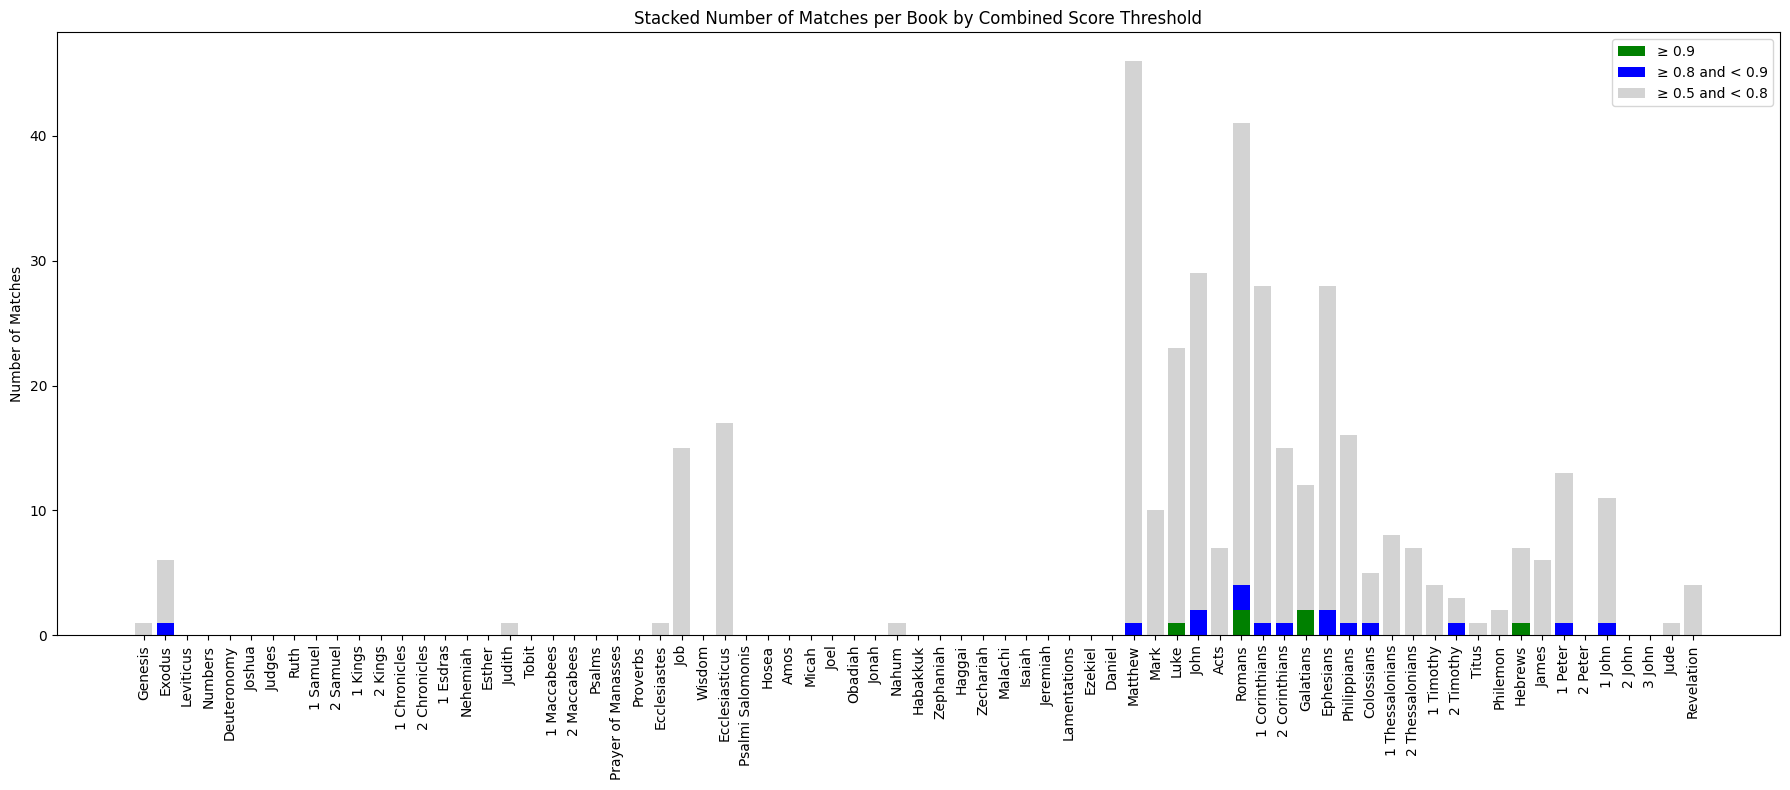

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Count per threshold
thresholds = [0.5, 0.8, 0.9]
threshold_counts = {
    t: matches_filtered_df[matches_filtered_df["combined_score"] >= t]["title"].value_counts()
    for t in thresholds
}

# Create DataFrame and reindex
plot_df = pd.DataFrame(threshold_counts).fillna(0).astype(int)
plot_df = plot_df.reindex(book_titles_sorted).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(18, 8))
x = range(len(plot_df))

# Colors by threshold
colors = {
    thresholds[2]: "green",
    thresholds[1]: "blue",
    thresholds[0]: "lightgray"
}

# Stack the bars: 0.9 first, then 0.8–0.9, then 0.7–0.8
bottom_90 = plot_df[thresholds[2]]
height_80 = plot_df[thresholds[1]] - bottom_90
height_70 = plot_df[thresholds[0]] - plot_df[thresholds[1]]

# Plot each stacked layer
ax.bar(x, bottom_90, color=colors[thresholds[2]], label=f'≥ {thresholds[2]}')
ax.bar(x, height_80, bottom=bottom_90, color=colors[thresholds[1]], label=f'≥ {thresholds[1]} and < {thresholds[2]}')
ax.bar(x, height_70, bottom=plot_df[thresholds[1]], color=colors[thresholds[0]], label=f'≥ {thresholds[0]} and < {thresholds[1]}')

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=90, fontsize=10)
ax.set_ylabel("Number of Matches")
ax.set_title("Stacked Number of Matches per Book by Combined Score Threshold")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
Distributions of detected references to individual biblical books.Individual references are differentiated by color based on the cosine similarity score of the matched LaBSE embeddings. While values over 0.9 are mainly direct citation, values under 0.7 tend to be rather paraphrases.

In [187]:
fig.savefig("../figures/grela_register_ngram_comb_matches_v1.png", dpi=300)

In [202]:
# Create the co-occurrence table
cooc_df = merged_df.sort_values("combined_score")[:3000].pivot_table(
    index="subwork_id",
    columns="book",
    values="sentence",  # or any column that is non-null
    aggfunc="count",
    fill_value=0
)

# Reindex columns to follow your predefined order
cooc_df = cooc_df.reindex(columns=book_titles_sorted).fillna(0).astype(int)

In [203]:
cooc_df

book,Genesis,Exodus,Leviticus,Numbers,Deuteronomy,Joshua,Judges,Ruth,1 Samuel,2 Samuel,...,Philemon,Hebrews,James,1 Peter,2 Peter,1 John,2 John,3 John,Jude,Revelation
subwork_id,,,,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,1,0
100,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
102,0,0,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,0,0,2,0,0,0,0,0,0,...,0,2,0,0,0,1,0,0,0,0
96,1,0,1,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
97,1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [204]:
cooc_df_filtered = cooc_df[cooc_df.sum(axis=1)>5]

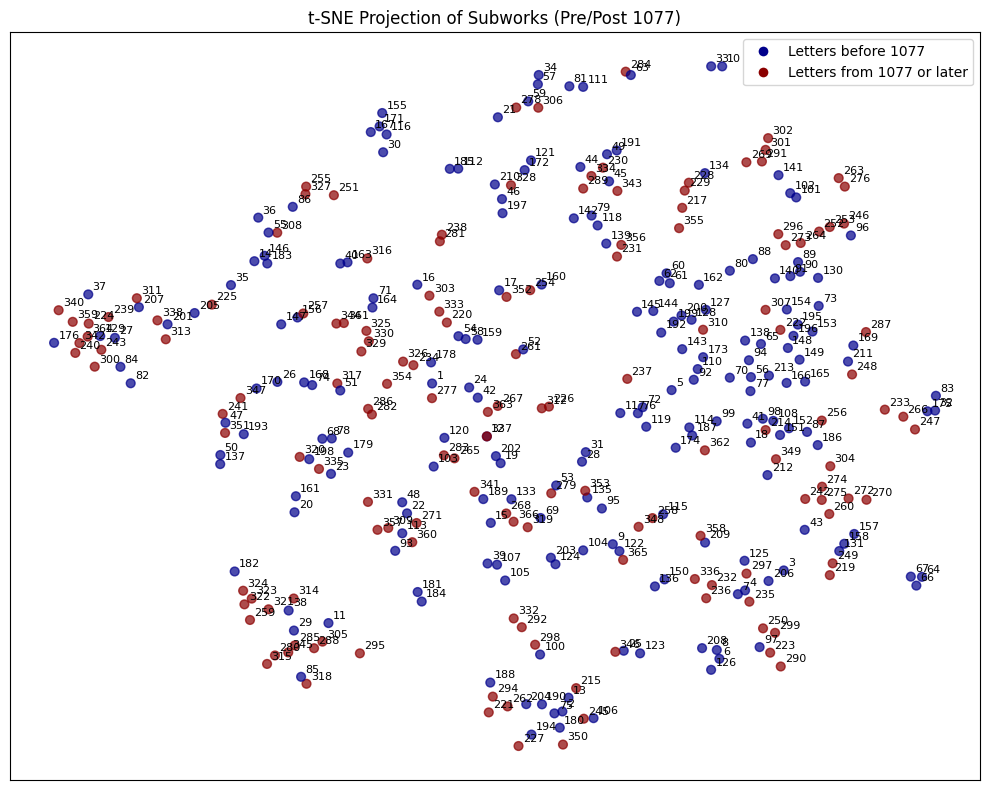

In [220]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=8, metric='cosine', random_state=42)
tsne_coords = tsne.fit_transform(cooc_df.values)

# Create DataFrame for plotting
tsne_df = pd.DataFrame({
    "x": tsne_coords[:, 0],
    "y": tsne_coords[:, 1],
    "subwork_id": cooc_df.index
})

# Determine colors based on subwork_id threshold
def get_color(subwork_id):
    try:
        return "darkred" if int(subwork_id) >= 214 else "darkblue"
    except:
        return "gray"

tsne_df["color"] = tsne_df["subwork_id"].apply(get_color)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    tsne_df["x"], tsne_df["y"],
    c=tsne_df["color"],
    s=40,
    alpha=0.7
)

# Optional: add text labels
for _, row in tsne_df.iterrows():
    ax.text(row["x"] + 0.5, row["y"] + 0.5, row["subwork_id"], fontsize=8)

# Formatting
ax.set_title("t-SNE Projection of Subworks (Pre/Post 1077)")
#ax.set_xlabel("t-SNE Dim 1")
#ax.set_ylabel("t-SNE Dim 2")
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Letters before 1077', markerfacecolor='darkblue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Letters from 1077 or later', markerfacecolor='darkred', markersize=8)
]
ax.legend(handles=legend_elements)

plt.tight_layout()
# Optionally save: fig.savefig("tsne_subwork_by_date.png")

Figure 1: 2-dimensional t-SNE projection of the distribution of references to Biblical books across individual letters. Dates differentiated by color.

In [219]:
fig.savefig("../figures/grela_register_ngram_comb_matches_v1_tsne.png", dpi=300)